UID: 22BAI71060
=== 1. Data Preparation ===


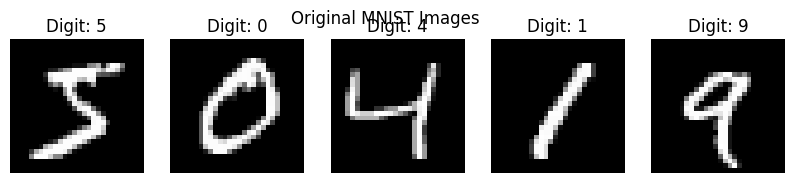

Training data shape: (60000, 784)
Test data shape: (10000, 784)

=== 2. Layerwise Pre-training ===

Training Layer 1

Building Autoencoder 1
Input dimension: 784 → Encoded dimension: 512
Epoch 1/5


In [ ]:

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

print("UID: 22BAI71060")

print("=== 1. Data Preparation ===")
# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Visualize some original images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Digit: {y_train[i]}')
    plt.axis('off')
plt.suptitle('Original MNIST Images')
plt.show()

# Normalize and reshape
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255
x_train = x_train.reshape((x_train.shape[0], 28 * 28))
x_test = x_test.reshape((x_test.shape[0], 28 * 28))
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

def build_autoencoder(input_dim, encoding_dim, layer_num):
    print(f"\nBuilding Autoencoder {layer_num}")
    print(f"Input dimension: {input_dim} → Encoded dimension: {encoding_dim}")
    
    input_img = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_img)
    decoded = Dense(input_dim, activation='sigmoid')(encoded)
    
    autoencoder = Model(input_img, decoded)
    encoder = Model(input_img, encoded)
    
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    return autoencoder, encoder

print("\n=== 2. Layerwise Pre-training ===")
layer_dims = [512, 256, 128]
input_dim = x_train.shape[1]
autoencoders = []
encoders = []
encoded_input = x_train

# Train each layer's autoencoder
for i, encoding_dim in enumerate(layer_dims, 1):
    print(f"\nTraining Layer {i}")
    autoencoder, encoder = build_autoencoder(input_dim, encoding_dim, i)
    
    # Train and plot history
    history = autoencoder.fit(encoded_input, encoded_input,
                            epochs=5,
                            batch_size=256,
                            shuffle=True,
                            validation_split=0.2,
                            verbose=1)
    
    # Plot training loss
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Autoencoder {i} Training Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    
    encoded_input = encoder.predict(encoded_input)
    autoencoders.append(autoencoder)
    encoders.append(encoder)
    input_dim = encoding_dim
    
    print(f"Data shape after encoding: {encoded_input.shape}")

print("\n=== 3. Building Final Model ===")
# Define the DNN with pre-trained weights
model = Sequential()

# Add pre-trained layers
input_dim = x_train.shape[1]
for i, encoder in enumerate(encoders):
    if i == 0:
        model.add(Dense(encoder.layers[1].units, 
                       activation='relu', 
                       input_shape=(input_dim,),
                       name=f'pretrained_layer_{i+1}'))
    else:
        model.add(Dense(encoder.layers[1].units, 
                       activation='relu',
                       name=f'pretrained_layer_{i+1}'))
    model.layers[-1].set_weights(encoder.layers[1].get_weights())
    print(f"Added pre-trained layer {i+1} with {encoder.layers[1].units} neurons")
    input_dim = encoder.layers[1].units

# Add the output layer
model.add(Dense(10, activation='softmax', name='classification_layer'))
print("\nFinal Model Architecture:")
model.summary()

print("\n=== 4. Fine-tuning ===")
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

# Train and plot progress
history = model.fit(x_train, y_train, 
                   epochs=5,
                   batch_size=128, 
                   validation_split=0.2,
                   verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy During Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== 5. Model Evaluation ===")
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

# Show some predictions
print("\n=== Sample Predictions ===")
predictions = model.predict(x_test[:5])
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = np.argmax(y_test[i])
    plt.title(f'Pred: {pred_label}\nTrue: {true_label}')
    plt.axis('off')
plt.tight_layout()
plt.show()